<a href="https://colab.research.google.com/github/RichardHr08/Grupo1/blob/main/Actividad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Exploratiorio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/bssanchezlopez/Grupo_1/refs/heads/main/synthetic_fraud_dataset.csv")

a. ¿Cuántas filas y columnas tiene?

In [ ]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 50000
Columnas: 21


b. ¿Cuál es el target?

In [ ]:
print("Fraud_Label")

Fraud_Label


c. ¿Las etiquetas del target están balanceadas?

In [ ]:
df["Fraud_Label"].value_counts()


,count
Fraud_Label,
0,33933
1,16067


In [ ]:
df["Fraud_Label"].value_counts(normalize=True)

,proportion
Fraud_Label,
0,0.68
1,0.32


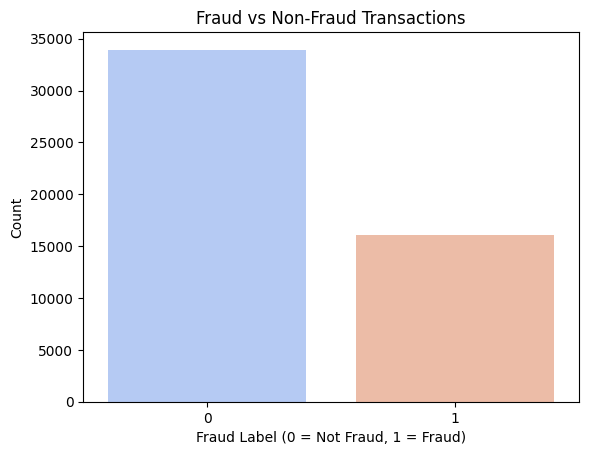

In [ ]:
sns.countplot(x=df['Fraud_Label'], palette='coolwarm')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

d. ¿Hay datos faltantes?

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Timestamp,0
Account_Balance,0
Device_Type,0
Location,0
Merchant_Category,0
IP_Address_Flag,0


e. ¿Hay datos fuera de serie?

In [ ]:
# 1. Identificar columnas numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Columnas numéricas:", num_cols)

# 2. Función para encontrar outliers por IQR
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# 3. Detectar outliers en cada columna numérica
outliers_total = pd.DataFrame()

for col in num_cols:
    outliers_col = detectar_outliers_iqr(df, col)
    if not outliers_col.empty:
        outliers_total = pd.concat([outliers_total, outliers_col])


print("\nFILAS CON OUTLIERS DETECTADOS:")
# 1. Identificar columnas numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Columnas numéricas:", num_cols)

# 2. Función para encontrar outliers por IQR
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# 3. Detectar outliers en cada columna numérica
outliers_total = pd.DataFrame()

for col in num_cols:
    outliers_col = detectar_outliers_iqr(df, col)
    if not outliers_col.empty:
        outliers_total = pd.concat([outliers_total, outliers_col])



print("\nFILAS CON OUTLIERS DETECTADOS:")
print(outliers_total)

Columnas numéricas: Index(['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
       'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')

FILAS CON OUTLIERS DETECTADOS:
Columnas numéricas: Index(['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
       'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')

FILAS CON OUTLIERS DETECTADOS:
      Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
10         TXN_43106  USER_2848              367.50              POS   
55         TXN_49146  USER_7335              308.73    Bank Transfer   
63         TXN_34657  USER_3467              306.60           

f. ¿Qué tipos de datos son? (numéricos, ordinales)

In [ ]:
df.dtypes

,0
Transaction_ID,object
User_ID,object
Transaction_Amount,float64
Transaction_Type,object
Timestamp,object
Account_Balance,float64
Device_Type,object
Location,object
Merchant_Category,object
IP_Address_Flag,int64


g. ¿Hay correlación entre los datos?

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


In [ ]:
df.corr()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
Transaction_ID,1.000000,-0.002803,-0.001192,-0.002015,0.007637,-0.001593,-0.000925,0.000635,0.006453,-0.004908,...,-0.001278,-0.001227,0.001538,0.003229,0.005675,-0.000125,-0.000753,0.000574,-0.003617,0.010258
User_ID,-0.002803,1.000000,-0.004986,0.001374,-0.003458,0.003199,0.007579,0.010200,-0.003132,-0.008774,...,-0.005699,-0.014434,-0.000258,-0.008777,0.007087,0.003589,-0.004182,-0.003056,0.006295,-0.004051
Transaction_Amount,-0.001192,-0.004986,1.000000,-0.002979,-0.008969,-0.002380,0.002216,-0.000387,0.000688,-0.001620,...,0.002149,-0.006255,0.001247,-0.007021,0.002294,0.007935,-0.003419,0.005606,0.001348,0.001901
Transaction_Type,-0.002015,0.001374,-0.002979,1.000000,-0.003495,0.001635,-0.003761,-0.004690,-0.004063,0.003392,...,-0.002810,-0.002300,0.001111,0.001488,-0.000554,0.004412,-0.006421,-0.001657,-0.000517,-0.004592
Timestamp,0.007637,-0.003458,-0.008969,-0.003495,1.000000,0.002256,0.006231,-0.003742,0.003791,-0.003842,...,-0.000131,0.000095,0.002380,0.012036,0.002132,-0.004084,-0.003689,-0.005391,-0.002152,-0.000739
Account_Balance,-0.001593,0.003199,-0.002380,0.001635,0.002256,1.000000,0.004888,0.001449,0.000988,-0.001210,...,0.006041,-0.001738,-0.000186,0.009316,0.000717,0.001748,0.005909,-0.005262,0.000557,-0.003153
Device_Type,-0.000925,0.007579,0.002216,-0.003761,0.006231,0.004888,1.000000,-0.007267,-0.000276,0.004829,...,0.001472,0.001525,0.001338,-0.004591,0.001242,-0.002684,-0.003559,0.004890,0.005808,0.005368
Location,0.000635,0.010200,-0.000387,-0.004690,-0.003742,0.001449,-0.007267,1.000000,-0.001583,0.005000,...,-0.006473,0.001273,0.003663,0.006175,-0.002858,0.013283,-0.000884,0.001097,0.006440,0.004680
Merchant_Category,0.006453,-0.003132,0.000688,-0.004063,0.003791,0.000988,-0.000276,-0.001583,1.000000,-0.000463,...,-0.004915,-0.003100,0.003878,0.001943,0.004177,-0.001524,0.003985,-0.001074,-0.000491,0.005734
IP_Address_Flag,-0.004908,-0.008774,-0.001620,0.003392,-0.003842,-0.001210,0.004829,0.005000,-0.000463,1.000000,...,0.001815,-0.004845,0.010370,0.007230,-0.003143,-0.003941,0.001438,-0.004064,0.004979,0.003028


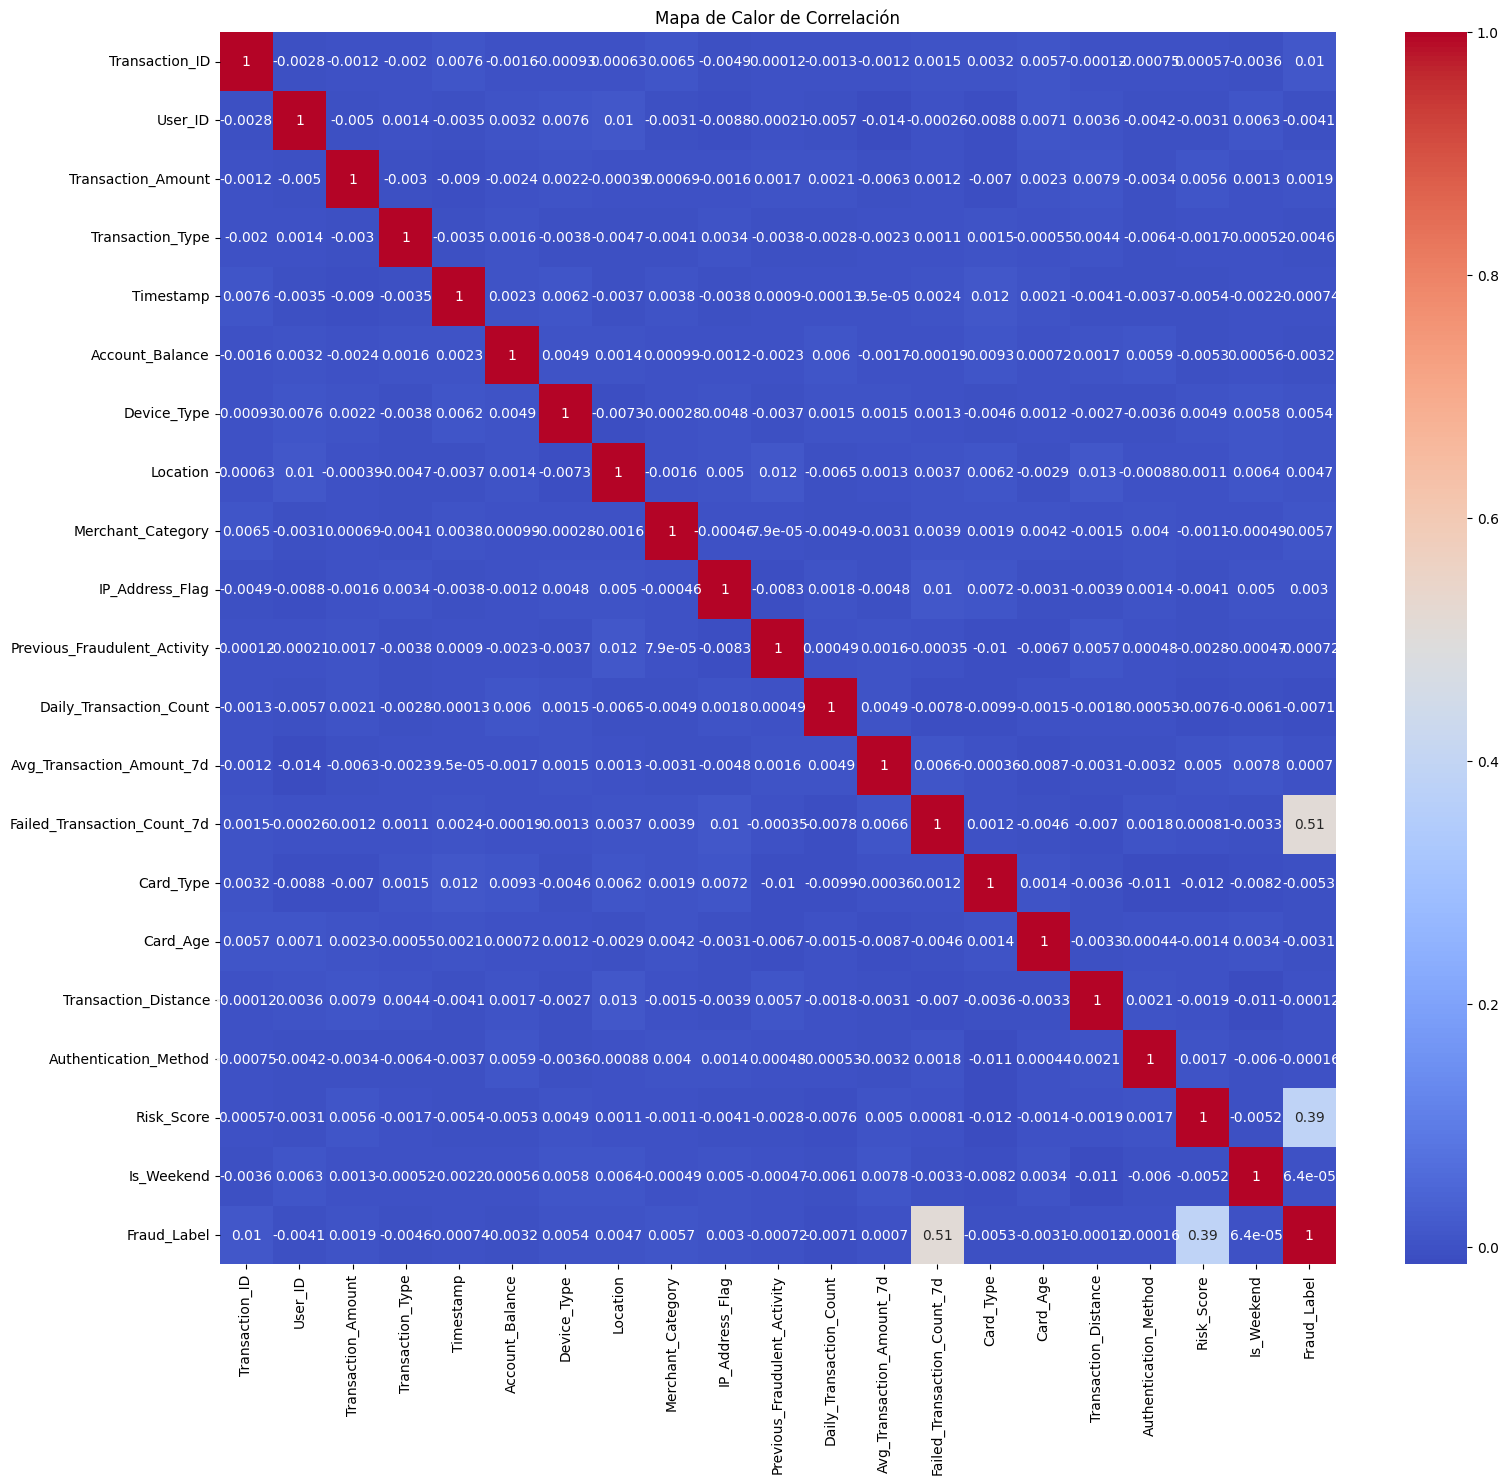

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(18,16))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de Calor de Correlación")
plt.show()

# Procesamiento de datos

¿Qué tratamiento requieren tus datos?

La columna "Timestamp" se debe convertir en tipo de datos fecha ademas los tipo object en numerico de ser necesario.

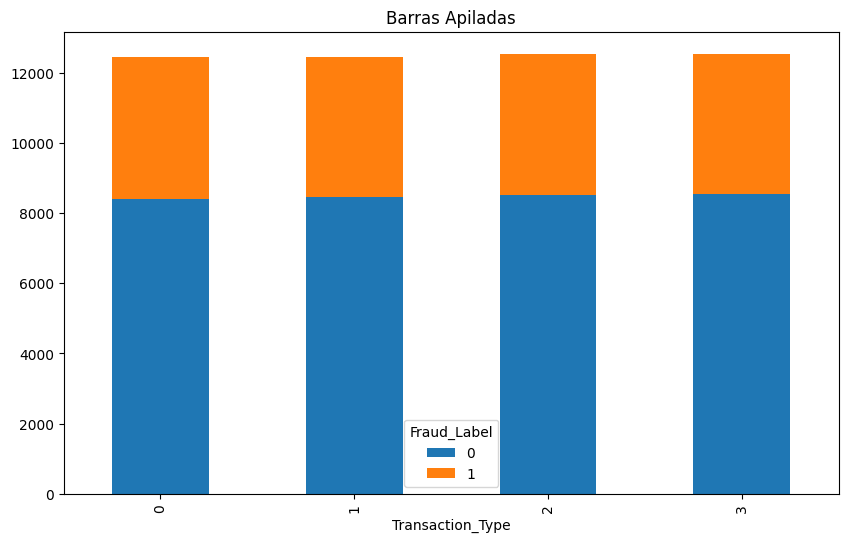

In [ ]:
import seaborn as sns

tabla = df.groupby(["Transaction_Type", "Fraud_Label"]).size().reset_index(name="count")

tabla_pivot = tabla.pivot(index="Transaction_Type", columns="Fraud_Label", values="count")

tabla_pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Barras Apiladas")
plt.show()

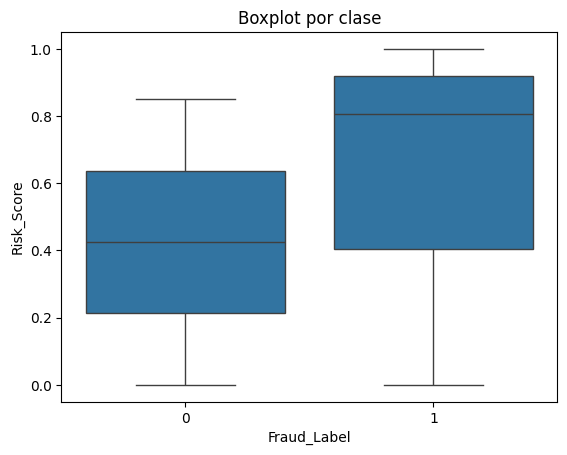

In [ ]:
sns.boxplot(x=df["Fraud_Label"], y=df["Risk_Score"])
plt.title("Boxplot por clase")
plt.show()

# Generación de modelos  

a) Uso de LazyPredict (1 punto)

In [3]:
pip install lazypredict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [5]:
df.drop([
    'Transaction_ID',
    'User_ID',
    'Timestamp',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Card_Type',
    'Authentication_Method',
    'Risk_Score'
], axis=1, inplace=True)

In [15]:
X = df.drop("Fraud_Label", axis=1)
y = df["Fraud_Label"]

In [16]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

import lazypredict

In [17]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# 1. Take a smaller sample (e.g., 20% of your data) for the "Lazy" check
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_train, y_train, train_size=0.20, random_state=42, stratify=y_train
)


# 2. Run LazyClassifier on the smaller set
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_small, X_test_small, y_train_small, y_test_small)

print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2566, number of negative: 5434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1295
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320750 -> initscore=-0.750327
[LightGBM] [Info] Start training from score -0.750327
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
AdaBoostClassifier                 0.88               0.81     0.81      0.87   
RandomForestClassifier             0.88               0.81     0.81      0.87   
ExtraTreesClassifier               0.88               0.81     0.81      0.87   
LGBMClassifier                     0.88 

b. Selección de 1 modelo y nuevo entrenamiento (1 punto)


In [9]:
pip install lightgbm

In [18]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

modelo_lgbm = LGBMClassifier(
    objective='binary',         # Para clasificación binaria. Usa 'multiclass' para más de 2 clases.
    n_estimators=1000,          # Número de árboles (iteraciones)
    learning_rate=0.05,         # Tasa de aprendizaje
    random_state=42,            # Para resultados reproducibles
    n_jobs=-1                   # Usar todos los núcleos de CPU disponibles
)

# 2. Entrenar el modelo con los datos de entrenamiento
print("Entrenando el modelo...")
modelo_lgbm.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenando el modelo...
[LightGBM] [Info] Number of positive: 12832, number of negative: 27168
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320800 -> initscore=-0.750098
[LightGBM] [Info] Start training from score -0.750098
Entrenamiento completado.


c. Optimización de hiperparámetros con CV=5 (2 puntos)


In [19]:
# 1. Hacer predicciones en el conjunto de prueba
y_pred = modelo_lgbm.predict(X_test)

# 2. Evaluar la precisión (accuracy)
precision = accuracy_score(y_test, y_pred)

print(f"\n✅ Precisión (Accuracy) del modelo en datos de prueba: {precision:.4f}")


✅ Precisión (Accuracy) del modelo en datos de prueba: 0.8761


In [20]:
from sklearn.model_selection import cross_val_score

# Crea una nueva instancia del modelo
modelo_cv = LGBMClassifier(random_state=42)

# Ejecuta la validación cruzada con K=5 pliegues
puntuaciones = cross_val_score(modelo_cv, X, y, cv=5, scoring='accuracy')

print(f"Puntuaciones de CV: {puntuaciones}")
print(f"Media de la Precisión de CV: {puntuaciones.mean():.4f}")
print(f"Desviación Estándar de la Precisión: {puntuaciones.std():.4f}")

[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[LightGBM] [Info] Start training from score -0.747575
[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[L

In [22]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# 1. Definir modelo base
lgbm = LGBMClassifier(random_state=123)

# 2. Definir la grid de hiperparámetros
param_grid = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'max_depth': [-1, 5, 10]
}

# 3. GridSearch con CV=5
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',   # puedes usar 'roc_auc' si tu dataset es desbalanceado
    n_jobs=-1,            # usa todos los núcleos de tu CPU
    verbose=1
)

# 4. Entrenar la búsqueda
grid.fit(X_train, y_train)

# 5. Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros:", grid.best_params_)

# 6. Mostrar el mejor score promedio de validación
print("Mejor score CV:", grid.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 12832, number of negative: 27168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320800 -> initscore=-0.750098
[LightGBM] [Info] Start training from score -0.750098
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 70}
Mejor score CV: 0.8779250000000001


In [24]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

modelo_lgbm = LGBMClassifier(
    max_depth=-1,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    num_leaves=70          )

# 2. Entrenar el modelo con los datos de entrenamiento
print("Entrenando el modelo...")
modelo_lgbm.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenando el modelo...
[LightGBM] [Info] Number of positive: 12832, number of negative: 27168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320800 -> initscore=-0.750098
[LightGBM] [Info] Start training from score -0.750098
Entrenamiento completado.


Accuracy: 0.8773
Precision: 1.0
Recall: 0.620710973724884
F1 Score: 0.7659736791913027
ROC-AUC: 0.8131552414863759


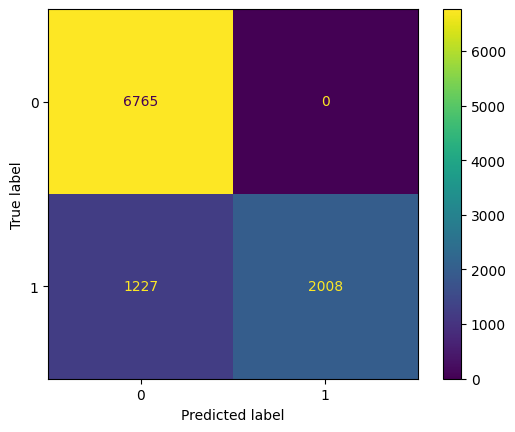

In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# 1. Predicciones
y_pred = modelo_lgbm.predict(X_test)
y_proba = modelo_lgbm.predict_proba(X_test)[:, 1]

# 2. Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# 3. Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [26]:
import joblib

In [35]:
joblib.dump(modelo_lgbm, "modelo_LGBMClassifier.pkl")
print("Modelo guardado modelo_LGBMClassifier.pkl")

Modelo guardado modelo_LGBMClassifier.pkl


In [36]:
# Este archivo se guarda en la carpeta temporal de Colab. Puedes descargarlo así:
from google.colab import files
files.download('modelo_LGBMClassifier.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>